In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline
import pyvista as pv
import meshio
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

poly = pv.read("Run2.vtk")

# 2. 三角化（还是 PolyData）
poly_tri = poly.triangulate()

# 3. 转成 UnstructuredGrid（关键步骤）
ugrid = pv.UnstructuredGrid(poly_tri)

# 4. 保存成 VTK（现在是 UNSTRUCTURED_GRID 格式）
ugrid.save("Run2_tri.vtk")

# 5. 用 meshio 读取
mesh = meshio.read("Run2_tri.vtk")

print(mesh.cells_dict.keys())  # 应该有 triangle


# 检查有哪些 point_data 变量
print("Point Data Arrays:", mesh.point_data.keys())


dict_keys(['triangle'])
Point Data Arrays: dict_keys(['U', 'Ux', 'alpha.water', 'enstrophy', 'p', 'vorticity'])


<>:56: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\e'
C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_28180\3595041748.py:56: SyntaxWarning: invalid escape sequence '\e'
  cbar.set_label('$\epsilon [s^{-2}]$', fontsize=14, fontweight='bold')


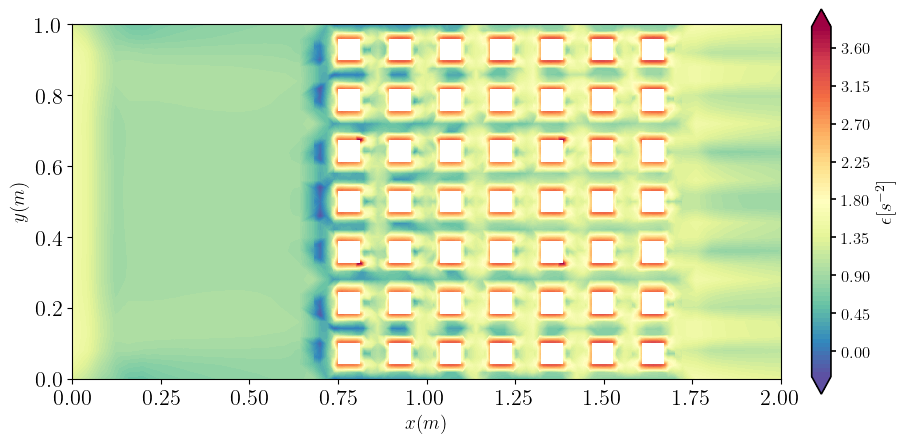

In [26]:
# === 3. 选择你要画的字段 ===
# 假设是速度 U（向量），取大小

points = mesh.points
x = points[:, 0]

y = points[:, 1]

#vorticity = mesh.point_data['vorticity']      # N x 3 数组

#u, v = vorticity[:, 0], vorticity[:, 1]   # 取平面内的分量

#magU = np.linalg.norm(vorticity, axis=1)
# 如果是标量，比如压力 p

enstrophy = mesh.point_data['enstrophy']

# 取 log10（可选）
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# === 4. 获取单元拓扑信息 ===
# VTK 切面文件通常是三角形面（triangle）
cells = mesh.cells_dict.get("triangle")

if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元，可能是其他单元类型。")

# === 5. 构造 Triangulation ===
# 这里选择 x-z 平面作图（你也可以改成 x-y 或 y-z）

triang = tri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], cells)

# === 6. 画等值图 ===
# 根据数据范围调整aspect ratio
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range



fig, ax = plt.subplots(figsize=(10, 10*aspect_ratio))  # 动态设置图形大小
ax.set_aspect('equal')

tpc = ax.tricontourf(triang, enstrophy, cmap='Spectral_r',levels=100,extend='both')

# 画网格边界（可选）
# ax.triplot(triang, 'k-', linewidth=0.3)

ax.set_xlim(x.min(), 2.0)

# === 8. 美化颜色条 ===
cbar = fig.colorbar(tpc, ax=ax, orientation='vertical',
                    fraction=0.046, pad=0.04)  # 控制位置


cbar.set_label('$\epsilon [s^{-2}]$', fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_tick_params(width=1.2)  # 刻度线粗细
cbar.outline.set_linewidth(1.2)           # 边框粗细

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

plt.xlabel('$x (m)$', **ticklabel_style)
plt.ylabel('$y (m)$', **ticklabel_style)
#plt.title('Vorticity magnitude on cutPlane', **ticklabel_style)

#plt.savefig('cutPlane_colormap.png', dpi=400)
plt.show()




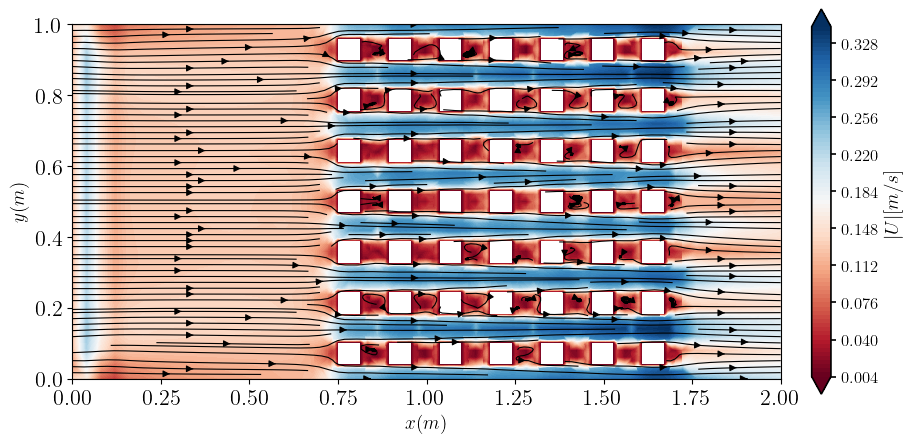

In [24]:
# === 3. 选择你要画的字段 ===
# 假设是速度 U（向量），取大小

points = mesh.points
x = points[:, 0]

y = points[:, 1]

U = mesh.point_data['U']      # N x 3 数组

u, v = U[:, 0], U[:, 1]   # 取平面内的分量

magU = np.linalg.norm(U, axis=1)
#magU = np.where(magU < 1e-12, -12., np.log10(magU))
# 如果是标量，比如压力 p

#enstrophy = mesh.point_data['enstrophy']

# 取 log10（可选）
#enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# === 4. 获取单元拓扑信息 ===
# VTK 切面文件通常是三角形面（triangle）
cells = mesh.cells_dict.get("triangle")

if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元，可能是其他单元类型。")

# === 5. 构造 Triangulation ===
# 这里选择 x-z 平面作图（你也可以改成 x-y 或 y-z）

triang = tri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], cells)

# === 6. 画等值图 ===
# 根据数据范围调整aspect ratio
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

fig, ax = plt.subplots(figsize=(10, 10*aspect_ratio))  # 动态设置图形大小
ax.set_aspect('equal')

tpc = ax.tricontourf(triang, magU, cmap='RdBu',levels=100,extend='both')

# 画网格边界（可选）
# ax.triplot(triang, 'k-', linewidth=0.3)
from scipy.interpolate import griddata

# === 7.1 建立规则网格用于 streamplot ===
# 注意：这里应该是x-z平面，所以用x和z的范围
nx, nz = 200, 200   # 网格分辨率
xi = np.linspace(0, 2, nx)
zi = np.linspace(0, 1, nz)  # 注意：这里是z，不是y
XI, ZI = np.meshgrid(xi, zi)

# 把速度场插值到规则网格
# 使用x和z坐标作为插值点
Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# === 7.2 画流线 ===
# 修改streamplot的参数
ax.streamplot(
    XI, ZI, Ui, Vi,  # 注意：这里是ZI而不是YI
    color='k', density=2, linewidth=0.8, arrowsize=1
)


ax.set_xlim(x.min(), 2.0)

ax.set_ylim(y.min(), y.max())

# === 8. 美化颜色条 ===
cbar = fig.colorbar(tpc, ax=ax, orientation='vertical',
                    fraction=0.046, pad=0.04)  # 控制位置


cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_tick_params(width=1.2)  # 刻度线粗细
cbar.outline.set_linewidth(1.2)           # 边框粗细

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

plt.xlabel('$x (m)$', **ticklabel_style)
plt.ylabel('$y (m)$', **ticklabel_style)
#plt.title('Velocity magnitude on cutPlane', **ticklabel_style)

#plt.savefig('cutPlane_colormap.png', dpi=400)
plt.show()




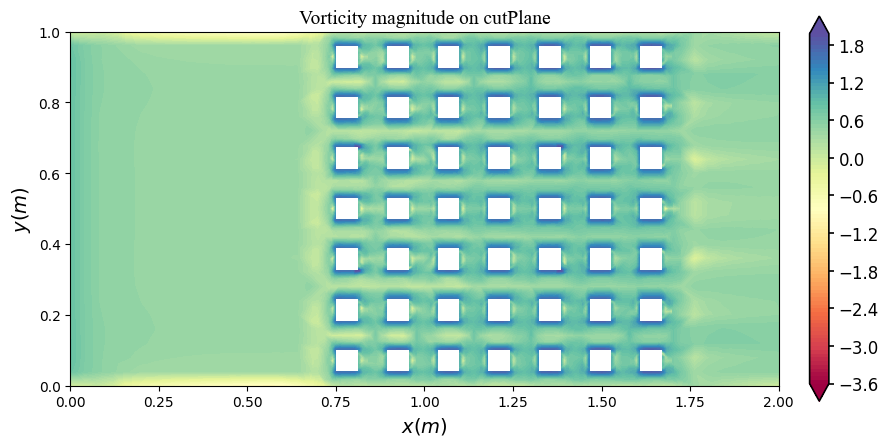

In [ ]:
# === 3. 选择你要画的字段 ===
# 假设是速度 U（向量），取大小

points = mesh.points
x = points[:, 0]

y = points[:, 1]

vorticity = mesh.point_data['vorticity']      # N x 3 数组

u, v = vorticity[:, 0], vorticity[:, 1]   # 取平面内的分量

magU = np.linalg.norm(vorticity, axis=1)

magU = np.where(magU < 1e-12, -12., np.log10(magU))
# 如果是标量，比如压力 p

#enstrophy = mesh.point_data['enstrophy']

# 取 log10（可选）
#enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# === 4. 获取单元拓扑信息 ===
# VTK 切面文件通常是三角形面（triangle）
cells = mesh.cells_dict.get("triangle")

if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元，可能是其他单元类型。")

# === 5. 构造 Triangulation ===
# 这里选择 x-z 平面作图（你也可以改成 x-y 或 y-z）

triang = tri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], cells)

# === 6. 画等值图 ===
# 根据数据范围调整aspect ratio
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

fig, ax = plt.subplots(figsize=(10, 10*aspect_ratio))  # 动态设置图形大小
ax.set_aspect('equal')

tpc = ax.tricontourf(triang, magU, cmap='Spectral',levels=100,extend='both')

# 画网格边界（可选）
# ax.triplot(triang, 'k-', linewidth=0.3)

ax.set_xlim(x.min(), 2.0)

# === 8. 美化颜色条 ===
cbar = fig.colorbar(tpc, ax=ax, orientation='vertical',
                    fraction=0.046, pad=0.04)  # 控制位置


#cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_tick_params(width=1.2)  # 刻度线粗细
cbar.outline.set_linewidth(1.2)           # 边框粗细

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

plt.xlabel('$x (m)$', **ticklabel_style)
plt.ylabel('$y (m)$', **ticklabel_style)
plt.title('Vorticity magnitude on cutPlane', **ticklabel_style)

#plt.savefig('cutPlane_colormap.png', dpi=400)
plt.show()




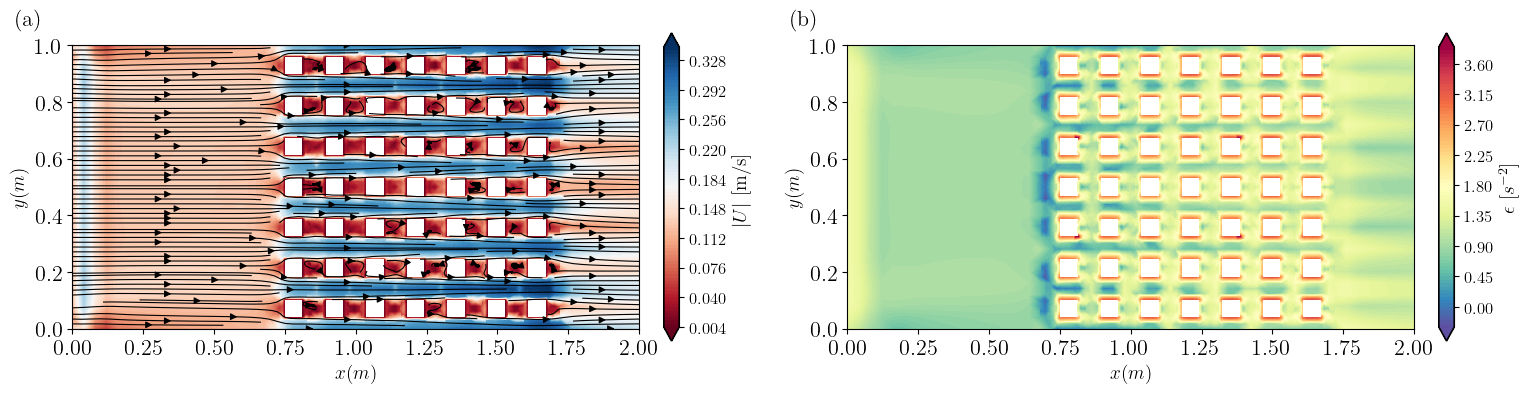

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run2.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run2_tri.vtk")

mesh = meshio.read("Run2_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 2, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================
fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(a)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)
cbar2.set_label('$\\epsilon$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(b)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.show()


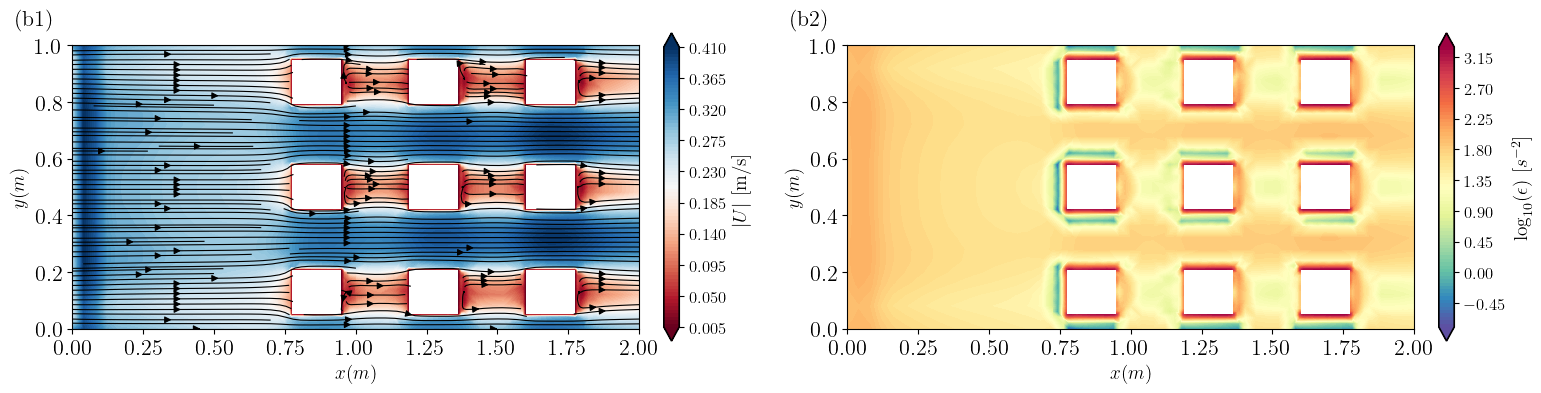

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run10.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run10_tri.vtk")

mesh = meshio.read("Run10_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 2, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================
fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(b1)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)
cbar2.set_label('$\\log_{10}(\\epsilon)$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(b2)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.savefig('Fig6(b).jpg', dpi=600, bbox_inches='tight')

plt.show()


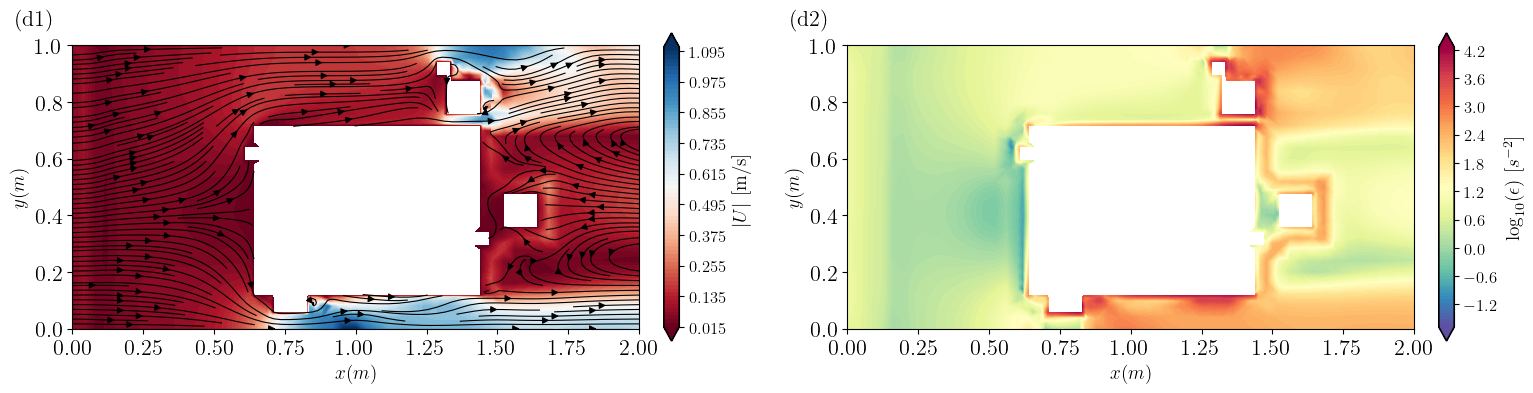

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run12.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run12_tri.vtk")

mesh = meshio.read("Run12_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 2, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================
fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(d1)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)
cbar2.set_label('$\\log_{10}(\\epsilon)$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(d2)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.savefig('Fig6(d).jpg', dpi=600, bbox_inches='tight')
plt.show()


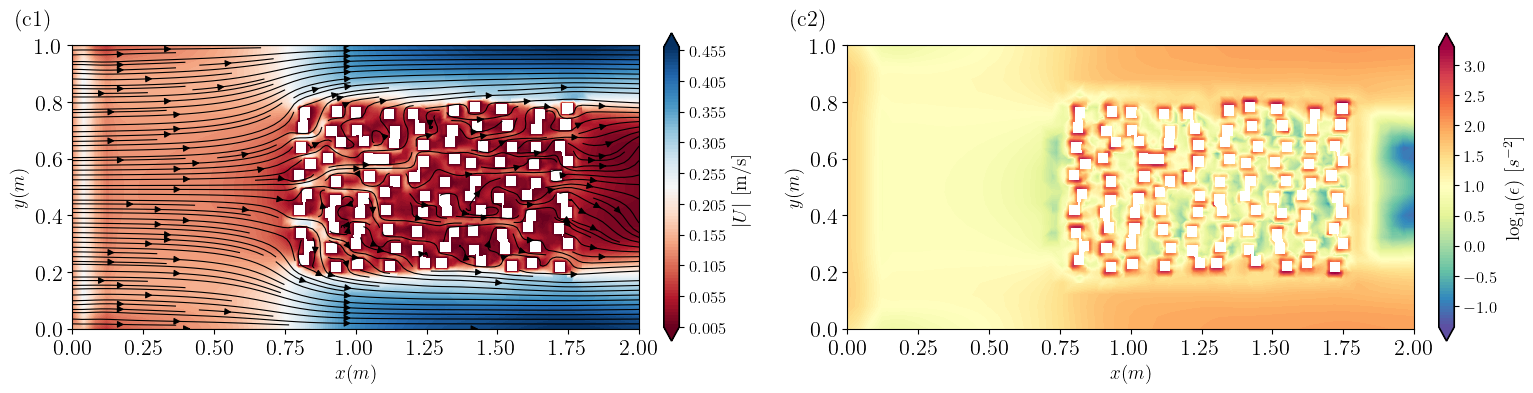

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run11.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run11_tri.vtk")

mesh = meshio.read("Run11_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 2, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================
fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(c1)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)
cbar2.set_label('$\\log_{10}(\\epsilon)$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(c2)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.savefig('Fig6(c).jpg', dpi=600, bbox_inches='tight')

plt.show()


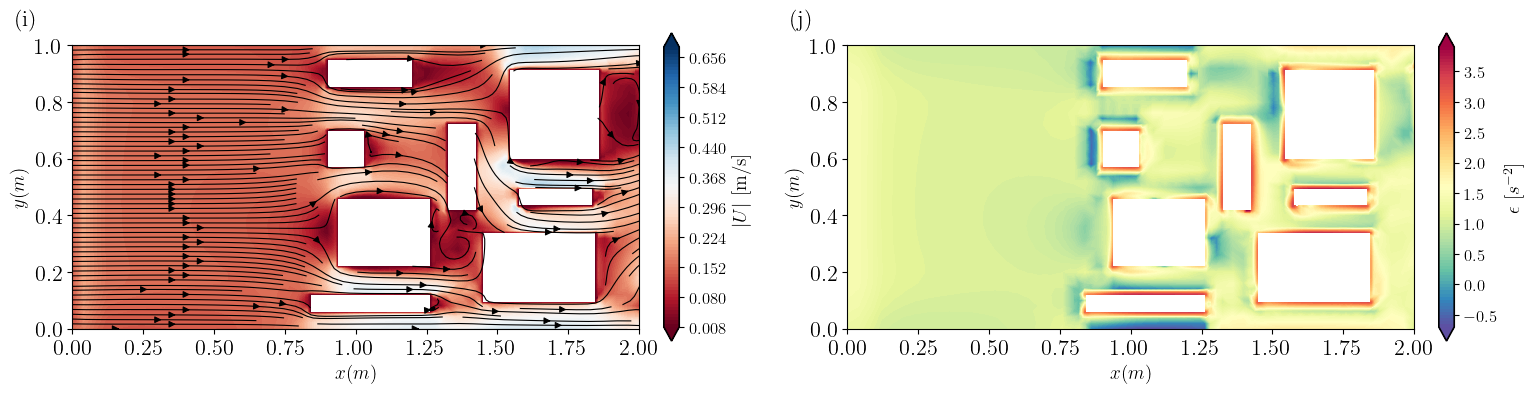

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run13.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run13_tri.vtk")

mesh = meshio.read("Run13_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 3, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================

# === 1. Matplotlib 全局字体设置 ===
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ['Times New Roman'],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "text.usetex": True,
    "figure.figsize": (12, 5)})

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 16}

fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(i)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)
cbar2.set_label('$\\epsilon$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(j)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.show()


<>:135: SyntaxWarning: invalid escape sequence '\l'
<>:135: SyntaxWarning: invalid escape sequence '\l'
C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_21432\2531980644.py:135: SyntaxWarning: invalid escape sequence '\l'
  cbar2.set_label('$\log_{10}(\epsilon)$ [$s^{-2}$]', fontsize=14, fontweight='bold')


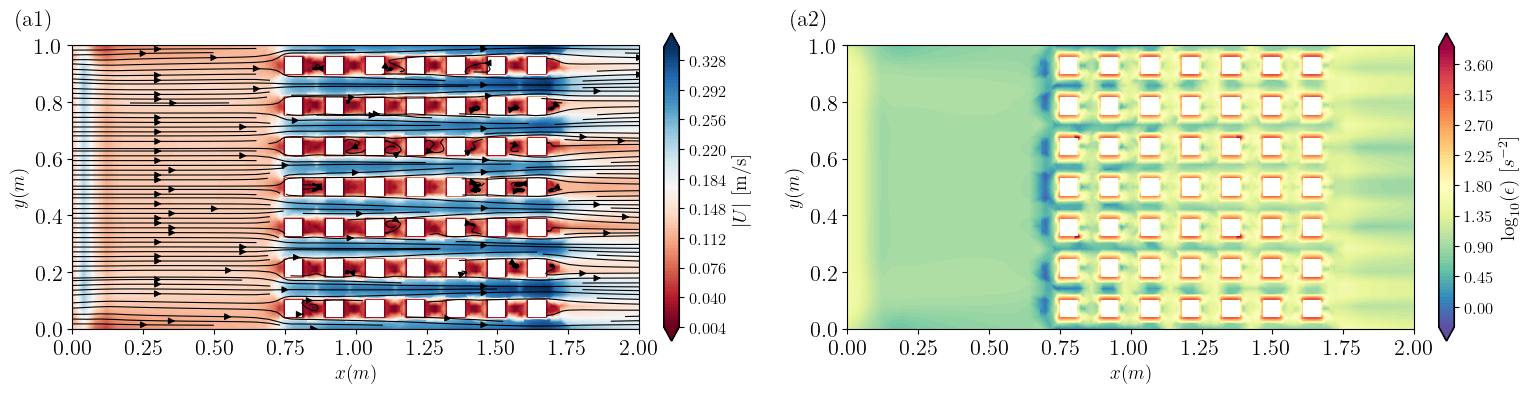

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
import pyvista as pv
import meshio

# ===============================
# 1. 读取并转换 VTK
# ===============================
poly = pv.read("Run2.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("Run2_tri.vtk")

mesh = meshio.read("Run2_tri.vtk")

# ===============================
# 2. 基础数据
# ===============================
points = mesh.points
x = points[:, 0]
y = points[:, 1]

cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

triang = tri.Triangulation(x, y, cells)

# aspect ratio（与你原来一致）
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

# ===============================
# 3. 速度场 |U|
# ===============================
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]
magU = np.linalg.norm(U, axis=1)

# streamplot 插值网格
nx, nz = 200, 200
xi = np.linspace(0, 3, nx)
zi = np.linspace(y.min(), y.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

Ui = griddata(points[:, :2], u, (XI, ZI), method='linear')
Vi = griddata(points[:, :2], v, (XI, ZI), method='linear')

# ===============================
# 4. Enstrophy
# ===============================
enstrophy = mesh.point_data['enstrophy']
enstrophy = np.where(enstrophy < 1e-12, -12., np.log10(enstrophy))

# ===============================
# 5. 合并绘图
# ===============================

# === 1. Matplotlib 全局字体设置 ===
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ['Times New Roman'],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "text.usetex": True,
    "figure.figsize": (12, 5)})

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 16}

fig = plt.figure(figsize=(18, 8 * aspect_ratio))
gs = gridspec.GridSpec(1, 2, wspace=0.25)

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

# ---------- (a) |U| ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_aspect('equal')

tpc1 = ax1.tricontourf(
    triang, magU,
    cmap='RdBu', levels=100, extend='both'
)

ax1.streamplot(
    XI, ZI, Ui, Vi,
    color='k', density=2, linewidth=0.8, arrowsize=1
)

ax1.set_xlim(x.min(), 2.0)
ax1.set_ylim(y.min(), y.max())

ax1.set_xlabel('$x (m)$', **ticklabel_style)
ax1.set_ylabel('$y (m)$', **ticklabel_style)

cbar1 = fig.colorbar(
    tpc1, ax=ax1,
    fraction=0.046, pad=0.04
)
cbar1.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=12)
cbar1.outline.set_linewidth(1.2)

# 子图编号（图框外）
ax1.text(
    -0.1, 1.05, '(a1)',
    transform=ax1.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

# ---------- (b) Enstrophy ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_aspect('equal')

tpc2 = ax2.tricontourf(
    triang, enstrophy,
    cmap='Spectral_r', levels=100, extend='both'
)

ax2.set_xlim(x.min(), 2.0)
ax2.set_ylim(y.min(), y.max())

ax2.set_xlabel('$x (m)$', **ticklabel_style)
ax2.set_ylabel('$y (m)$', **ticklabel_style)

cbar2 = fig.colorbar(
    tpc2, ax=ax2,
    fraction=0.046, pad=0.04
)

cbar2.set_label('$log_{10}(\epsilon)$ [$s^{-2}$]', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=12)
cbar2.outline.set_linewidth(1.2)

ax2.text(
    -0.1, 1.05, '(a2)',
    transform=ax2.transAxes,
    fontsize=16, fontweight='bold',
    va='bottom', ha='left'
)

plt.savefig('Fig6(a).jpg', dpi=600, bbox_inches='tight')

plt.show()


In [7]:
from PIL import Image

def merge_images_horizontal(image_paths, output_path):
    # 1. 打开所有图片
    images = [Image.open(x) for x in image_paths]
    
    # 2. 计算总宽度和最大高度
    total_width = max(img.width for img in images)
    max_height = sum(img.height for img in images)
    
    # 3. 创建空白画布 (RGB 模式)
    new_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))
    
    # 4. 依次粘贴
    current_height = 0
    for img in images:
        new_img.paste(img, (0, current_height))
        current_height += img.height

    # 5. 保存
    new_img.save(output_path)
    print(f"拼接完成！已保存至: {output_path}")

# 使用示例


merge_images_horizontal(['Fig6(a).jpg', 'Fig6(b).jpg', 'Fig6(c).jpg', 'Fig6(d).jpg'], 'Fig6.jpg')

拼接完成！已保存至: Fig6.jpg
